# Notebook 05: CNN-LSTM-DANN with Polarity Alignment + Adapter

## Why the previous t-SNE showed two islands
The 5-dim shared space removed the zero-padding problem, but the t-SNE still showed
two completely separated arcs. Both arcs were smooth (the encoder IS capturing
degradation structure), but they curved in **opposite directions**.

**Root cause — polarity mismatch:**
- FD001 top-5 sensors (e.g. T50, Ps30) **decrease** as the engine degrades → positive correlation with RUL
- AI4I tool wear **increases** as the tool degrades → negative correlation with RUL

The encoder learned 'FD001 goes DOWN toward failure' and 'AI4I goes UP toward failure'.
These are mirror images → two islands, GRL cannot align them.

## Fix applied here
1. **Polarity check**: compute `sign(corr(feature, RUL))` for each FD001 feature and AI4I feature
2. **Polarity flip**: where signs differ, apply `x_new = 1 - x_old` to the AI4I feature
3. **Learnable adapter**: a `Dense(5, no activation)` layer applied to AI4I windows before
   they enter the shared encoder — handles residual rotation/scaling the flip alone misses

Expected result: both degradation arcs curve in the same direction → t-SNE overlap.

In [ ]:
# ── CELL 2: Imports & Setup ───────────────────────────────────────────────────
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, Model, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler
from sklearn.manifold        import TSNE

from src.data_loader          import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor         import full_preprocess_pipeline
from src.windowing            import (create_windows, create_windows_inference,
                                      create_windows_for_unit_lifecycle)
from src.models.cnn_lstm_dann import build_cnn_lstm_dann, get_cnn_lstm_feature_extractor
from src.models.grl           import GradientReversalLayer
from src.evaluate             import rmse, mae

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_SIZE = 30
MAX_RUL     = 125
SOURCE_DS   = 'FD001'
TARGET_DS   = 'AI4I'
DANN_N_FEAT = 5

AI4I_SENSOR_COLS = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

os.makedirs('../models/saved', exist_ok=True)
print(f'Source: {SOURCE_DS}  |  Target: {TARGET_DS}')
print(f'Shared feature space: {DANN_N_FEAT} dims  |  Window: {WINDOW_SIZE}')


Source: FD001  |  Target: AI4I
Shared feature space: 5 dims  |  Window: 30


In [11]:
# ── CELL 4: Source Domain — load FD001, select top-5, compute polarity ────────
datasets = load_all_datasets(data_dir='../data/raw')

df_tr_src, df_te_src, scaler_src = full_preprocess_pipeline(
    df_train         = datasets[SOURCE_DS]['train'],
    df_test          = datasets[SOURCE_DS]['test'],
    feature_cols     = FEATURE_COLS,
    sensor_cols      = SENSOR_COLS,
    smooth           = True,
    max_rul          = MAX_RUL,
    scaler_save_path = f'../models/saved/scaler_{SOURCE_DS}.joblib'
)

# Select top-5 FD001 features by |correlation with RUL|
corr_src = np.array([
    np.corrcoef(df_tr_src[col].values, df_tr_src['RUL'].values)[0, 1]
    for col in FEATURE_COLS
])
TOP5_IDX   = np.argsort(np.abs(corr_src))[::-1][:DANN_N_FEAT]
TOP5_COLS  = [FEATURE_COLS[i] for i in TOP5_IDX]
# Polarity: +1 if feature and RUL move in same direction, -1 if opposite
SRC_POLARITY = np.sign(corr_src[TOP5_IDX])   # shape (5,)

print('Top-5 FD001 features and their polarity with RUL:')
for rank, (col, idx) in enumerate(zip(TOP5_COLS, TOP5_IDX), 1):
    pol = 'SAME as RUL' if SRC_POLARITY[rank-1] > 0 else 'OPPOSITE to RUL'
    print(f'  {rank}. {col:<35}  corr={corr_src[idx]:+.4f}  ({pol})')

# Build windows, slice to top-5
X_src_all, y_src_raw, _ = create_windows(df_tr_src, FEATURE_COLS, window_size=WINDOW_SIZE)
X_src = X_src_all[:, :, TOP5_IDX].astype(np.float32)
y_src = (y_src_raw / MAX_RUL).astype(np.float32)

X_src_tr, X_src_val, y_src_tr, y_src_val = train_test_split(
    X_src, y_src, test_size=0.1, random_state=42
)
print(f'\nSource windows: train={X_src_tr.shape}  val={X_src_val.shape}')


Top-5 FD001 features and their polarity with RUL:
  1. op_setting_3                         corr=+nan  (OPPOSITE to RUL)
  2. sensor_4                             corr=-0.8245  (OPPOSITE to RUL)
  3. sensor_11                            corr=-0.8232  (OPPOSITE to RUL)
  4. sensor_15                            corr=-0.8193  (OPPOSITE to RUL)
  5. sensor_21                            corr=+0.8130  (SAME as RUL)

Source windows: train=(15867, 30, 5)  val=(1764, 30, 5)


/Users/skytan/ml/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/skytan/ml/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:
# ── CELL 6: Target Domain — AI4I with polarity alignment ─────────────────────
#
# WHY THE t-SNE SHOWED TWO ISLANDS (even after 5-dim fix)
# -------------------------------------------------------
# Both arcs were smooth, but they curved in OPPOSITE directions.
# FD001 sensors decrease toward failure  → positive corr with RUL.
# AI4I tool wear increases toward failure → negative corr with RUL.
# The encoder learned mirror-image trajectories → permanent separation.
#
# POLARITY ALIGNMENT FIX
# ----------------------
# For each of the 5 AI4I features:
#   1. Compute correlation with constructed RUL (or -tool_wear as proxy)
#   2. Compare sign with corresponding FD001 feature polarity
#   3. If signs differ → flip: x_new = 1.0 - x_old
# After this, both domains' features move in the SAME direction toward failure.
# The t-SNE arcs will curve together instead of in opposite directions.


def segment_ai4i_by_wear_reset(df_raw, wear_col='Tool wear [min]'):
    df = df_raw.copy().reset_index(drop=True)
    run_id, cycle_id = 0, 1
    run_ids, cycle_ids = [], []
    for i in range(len(df)):
        if i > 0 and df[wear_col].iloc[i] < df[wear_col].iloc[i - 1]:
            run_id += 1; cycle_id = 1
        run_ids.append(run_id); cycle_ids.append(cycle_id); cycle_id += 1
    df['unit_id'] = run_ids
    df['cycle']   = cycle_ids
    return df


ai4i_raw       = pd.read_csv('../data/raw/ai4i2020.csv')
ai4i_segmented = segment_ai4i_by_wear_reset(ai4i_raw)

# ── Step 1: normalise AI4I raw features to [0, 1] ─────────────────────────────
ai4i_scaler   = MinMaxScaler()
X_ai4i_raw    = ai4i_raw[AI4I_SENSOR_COLS].values.astype(np.float32)
X_ai4i_scaled = ai4i_scaler.fit_transform(X_ai4i_raw)

# ── Step 2: compute AI4I feature polarity vs constructed RUL ──────────────────
# Build a quick RUL column for correlation analysis only (not used in training)
ai4i_seg_tmp = ai4i_segmented.copy()
max_wear_tmp = ai4i_seg_tmp.groupby('unit_id')['Tool wear [min]'].max().rename('mw')
ai4i_seg_tmp = ai4i_seg_tmp.merge(max_wear_tmp, on='unit_id')
ai4i_rul_proxy = (ai4i_seg_tmp['mw'] - ai4i_seg_tmp['Tool wear [min]']).clip(upper=MAX_RUL).values

corr_tgt = np.array([
    np.corrcoef(X_ai4i_scaled[:, i], ai4i_rul_proxy)[0, 1]
    for i in range(DANN_N_FEAT)
])
TGT_POLARITY = np.sign(corr_tgt)

print('AI4I feature polarity with RUL:')
for i, col in enumerate(AI4I_SENSOR_COLS):
    pol = 'SAME as RUL' if TGT_POLARITY[i] > 0 else 'OPPOSITE to RUL'
    print(f'  {i+1}. {col:<35}  corr={corr_tgt[i]:+.4f}  ({pol})')

# ── Step 3: compute flip mask ─────────────────────────────────────────────────
# Flip AI4I feature i if its polarity differs from corresponding FD001 feature i
FLIP_MASK = (SRC_POLARITY != TGT_POLARITY)   # bool array, shape (5,)

print(f'\nPolarity alignment:')
for i, col in enumerate(AI4I_SENSOR_COLS):
    action = 'FLIP (1 - x)' if FLIP_MASK[i] else 'keep as-is'
    print(f'  {col:<35}  src_pol={SRC_POLARITY[i]:+.0f}  tgt_pol={TGT_POLARITY[i]:+.0f}  → {action}')

# ── Step 4: apply flip ────────────────────────────────────────────────────────
X_ai4i_aligned = X_ai4i_scaled.copy()
for i in range(DANN_N_FEAT):
    if FLIP_MASK[i]:
        X_ai4i_aligned[:, i] = 1.0 - X_ai4i_aligned[:, i]

n_flipped = FLIP_MASK.sum()
print(f'\n{n_flipped} feature(s) flipped. '
      f'Both domains now move in the same direction toward failure.')

# ── Step 5: build windows with proper unit_id/cycle ───────────────────────────
tgt_feature_cols = [f'ai4i_{i}' for i in range(DANN_N_FEAT)]
df_ai4i_tmp = pd.DataFrame(X_ai4i_aligned, columns=tgt_feature_cols)
df_ai4i_tmp['unit_id'] = ai4i_segmented['unit_id'].values
df_ai4i_tmp['cycle']   = ai4i_segmented['cycle'].values
df_ai4i_tmp['RUL']     = 0.5   # dummy — NOT used in training

X_tgt, _, _ = create_windows(df_ai4i_tmp, tgt_feature_cols, window_size=WINDOW_SIZE)
X_tgt = X_tgt.astype(np.float32)

print(f'\nSource shape: {X_src_tr.shape}  |  Target shape: {X_tgt.shape}')
print('Both (N, 30, 5) — identical structure, aligned polarity.')


AI4I feature polarity with RUL:
  1. Air temperature [K]                  corr=+0.0005  (SAME as RUL)
  2. Process temperature [K]              corr=+0.0066  (SAME as RUL)
  3. Rotational speed [rpm]               corr=-0.0062  (OPPOSITE to RUL)
  4. Torque [Nm]                          corr=+0.0089  (SAME as RUL)
  5. Tool wear [min]                      corr=-0.9163  (OPPOSITE to RUL)

Polarity alignment:
  Air temperature [K]                  src_pol=+nan  tgt_pol=+1  → FLIP (1 - x)
  Process temperature [K]              src_pol=-1  tgt_pol=+1  → FLIP (1 - x)
  Rotational speed [rpm]               src_pol=-1  tgt_pol=-1  → keep as-is
  Torque [Nm]                          src_pol=-1  tgt_pol=+1  → FLIP (1 - x)
  Tool wear [min]                      src_pol=+1  tgt_pol=-1  → FLIP (1 - x)

4 feature(s) flipped. Both domains now move in the same direction toward failure.

Source shape: (15867, 30, 5)  |  Target shape: (6420, 30, 5)
Both (N, 30, 5) — identical structure, aligned polarit

In [13]:
# ── CELL 8: Build DANN with Adapter Layer ────────────────────────────────────
#
# ADAPTER LAYER
# Polarity flip handles gross direction mismatch (mirror images).
# But residual differences remain: different sensor ranges, different
# noise levels, different physical units. A Dense(5) adapter with no
# activation learns a linear rotation/scaling to align these residuals.
#
# Architecture:
#   Source  → [shared CNN-LSTM encoder] → feature → regressor + discriminator
#   Target  → [Dense(5) adapter]        → [shared CNN-LSTM encoder] → discriminator
#
# The adapter is applied PER TIMESTEP (TimeDistributed) so it operates
# on each window step independently — shape (batch, 30, 5) → (batch, 30, 5).
# During training, source windows skip the adapter; target windows go through it.
# The GRL trains the shared encoder to be domain-invariant over both paths.


def build_dann_with_adapter(window_size, n_features,
                             filters, kernel_size, lstm_units,
                             feature_dim, reg_units, domain_units,
                             dropout_rate, reg_dropout, dom_dropout):
    """
    Returns: (reg_model, dann_model, adapter_model)
      reg_model     — source-only RUL predictor (used for evaluation)
      dann_model    — full DANN used for training (source path)
      adapter_model — Dense(5) adapter applied to target inputs
    """
    # ── Shared encoder (same as before) ──────────────────────────────────────
    from src.models.cnn_lstm_dann import build_cnn_lstm_dann
    reg_model, dann_model = build_cnn_lstm_dann(
        window_size  = window_size,
        n_features   = n_features,
        filters      = filters,
        kernel_size  = kernel_size,
        lstm_units   = lstm_units,
        feature_dim  = feature_dim,
        reg_units    = reg_units,
        domain_units = domain_units,
        dropout_rate = dropout_rate,
        reg_dropout  = reg_dropout,
        dom_dropout  = dom_dropout,
        alpha        = 0.0
    )

    # ── Target adapter: TimeDistributed Dense(5, linear) ──────────────────────
    # TimeDistributed applies the same Dense to every timestep independently.
    # No activation = purely linear rotation/scaling of the 5 features.
    # Initialised to identity so at epoch 0 the adapter is a no-op.
    adapter_inp = Input(shape=(window_size, n_features), name='adapter_input')
    adapter_out = layers.TimeDistributed(
        layers.Dense(
            n_features,
            use_bias          = True,
            kernel_initializer= 'identity',   # start as pass-through
            name              = 'adapter_dense'
        ),
        name = 'adapter_td'
    )(adapter_inp)
    adapter_model = Model(inputs=adapter_inp, outputs=adapter_out,
                          name='TargetAdapter')

    return reg_model, dann_model, adapter_model


reg_model, dann_model, adapter_model = build_dann_with_adapter(
    window_size  = WINDOW_SIZE,
    n_features   = DANN_N_FEAT,
    filters      = [32, 64],
    kernel_size  = 3,
    lstm_units   = 128,
    feature_dim  = 64,
    reg_units    = [64, 32],
    domain_units = [32],
    dropout_rate = 0.2,
    reg_dropout  = 0.2,
    dom_dropout  = 0.2
)

dann_model.summary()
print(f'\nAdapter: {adapter_model.count_params()} params (learns residual alignment)')
print(f'Initialised to identity matrix — epoch 0 is same as no adapter.')


Model: "CNN_LSTM_DANN_Full"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 32)    │        512 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 64)    │      6,208 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool             │ (None, 15, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout         │ (None, 15, 64)    │          0 │ maxpool[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │     98,816 │ cnn_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dropout        │ (None, 128)       │          0 │ lstm_1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_layer       │ (None, 64)        │      8,256 │ lstm_dropout[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_dense_1 (Dense) │ (None, 64)        │      4,160 │ feature_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_drop_1          │ (None, 64)        │          0 │ reg_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grl                 │ (None, 64)        │          0 │ feature_layer[0]… │
│ (GradientReversalL… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_dense_2 (Dense) │ (None, 32)        │      2,080 │ reg_drop_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_dense_1 (Dense) │ (None, 32)        │      2,080 │ grl[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_drop_2          │ (None, 32)        │          0 │ reg_dense_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_drop_1          │ (None, 32)        │          0 │ dom_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         33 │ reg_drop_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ domain_output       │ (None, 1)         │         33 │ dom_drop_1[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 122,178 (477.26 KB)

 Trainable params: 122,178 (477.26 KB)

 Non-trainable params: 0 (0.00 B)


Adapter: 30 params (learns residual alignment)
Initialised to identity matrix — epoch 0 is same as no adapter.


In [14]:
# ── CELL 10: Training with Adapter ───────────────────────────────────────────
from src.train import LSTMDANNTrainer


def sigmoid_lambda_schedule(epoch, total_epochs, gamma=5.0):
    p = epoch / max(total_epochs - 1, 1)
    return float(2.0 / (1.0 + np.exp(-gamma * p)) - 1.0)


trainer = LSTMDANNTrainer(dann_model, alpha=0.0, lr_reg=1e-3, lr_dom=5e-4)

# Separate optimiser for the adapter — same LR as regression
adapter_opt = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Over-sample target
n_src = len(X_src_tr)
if len(X_tgt) < n_src:
    repeat    = int(np.ceil(n_src / len(X_tgt)))
    X_tgt_use = np.tile(X_tgt, (repeat, 1, 1))[:n_src]
else:
    X_tgt_use = X_tgt[:n_src]

EPOCHS          = 220
BATCH_SIZE      = 256
PATIENCE        = 40
LR_DECAY_EP     = 100
WARM_RESTART_EP = 150
n_batches       = int(np.ceil(n_src / BATCH_SIZE))

grl_layer = dann_model.get_layer('grl')

rul_losses, dom_losses, val_maes = [], [], []
best_val = np.inf
no_imp   = 0
best_w_dann    = None
best_w_adapter = None


@tf.function(reduce_retracing=True)
def adapter_dann_step(X_src_b, y_src_b, X_tgt_b, lam_val):
    """
    One training step with adapter:
      Pass 1: source → DANN (regression + feature update)
      Pass 2: target → adapter → DANN (domain adversarial update)
              adapter weights also updated via domain loss
    """
    batch  = tf.shape(X_src_b)[0]
    d_src  = tf.zeros((batch, 1), dtype=tf.float32)
    d_tgt  = tf.ones((tf.shape(X_tgt_b)[0], 1), dtype=tf.float32)

    # Pass 1: regression on source (no adapter involved)
    with tf.GradientTape() as t1:
        rul_pred, _ = dann_model(X_src_b, training=True)
        rul_loss    = tf.reduce_mean(tf.abs(
            y_src_b[:, tf.newaxis] - rul_pred
        ))
    feat_reg_vars = [v for l in dann_model.layers
                     if not l.name.startswith('dom_') and l.name != 'domain_output'
                     and l.name != 'grl'
                     for v in l.trainable_variables]
    g1 = t1.gradient(rul_loss, feat_reg_vars)
    g1 = [g if g is not None else tf.zeros_like(v)
          for g, v in zip(g1, feat_reg_vars)]
    trainer.reg_opt.apply_gradients(zip(g1, feat_reg_vars))

    # Pass 2: domain adversarial — target goes through adapter first
    X_tgt_adapted = adapter_model(X_tgt_b, training=True)
    X_both = tf.concat([X_src_b, X_tgt_adapted], axis=0)
    d_both = tf.concat([d_src,   d_tgt],          axis=0)

    with tf.GradientTape() as t2:
        _, dom_pred = dann_model(X_both, training=True)
        dom_loss    = tf.keras.losses.binary_crossentropy(
            d_both, dom_pred
        )
        dom_loss = tf.reduce_mean(dom_loss)

    dom_vars     = [v for l in dann_model.layers
                    if l.name.startswith('dom_') or l.name == 'domain_output'
                    for v in l.trainable_variables]
    adapter_vars = adapter_model.trainable_variables
    all_dom_vars = dom_vars + adapter_vars

    g2 = t2.gradient(dom_loss, all_dom_vars)
    g2 = [g if g is not None else tf.zeros_like(v)
          for g, v in zip(g2, all_dom_vars)]
    trainer.dom_opt.apply_gradients(zip(g2, all_dom_vars))

    return rul_loss, dom_loss


print('Starting DANN training with polarity alignment + adapter...')
print(f'Source: {X_src_tr.shape}  |  Target: {X_tgt_use.shape}')
print(f'Gamma=5 (slow lambda ramp)  |  Adapter initialised to identity')
print(f'Convergence target: domain loss → {np.log(2):.4f}\n')

for epoch in range(EPOCHS):
    lam = sigmoid_lambda_schedule(epoch, EPOCHS, gamma=5.0)
    grl_layer.alpha = tf.cast(lam, tf.float32)

    if epoch == LR_DECAY_EP:
        trainer.reg_opt.learning_rate.assign(
            float(trainer.reg_opt.learning_rate) * 0.1)
        trainer.dom_opt.learning_rate.assign(
            float(trainer.dom_opt.learning_rate) * 0.1)
        print(f'  [ep {epoch}] LR decayed x0.1')

    if epoch == WARM_RESTART_EP:
        trainer.reg_opt.learning_rate.assign(3e-4)
        trainer.dom_opt.learning_rate.assign(5e-4)
        print(f'  [ep {epoch}] Warm restart')

    src_idx = np.random.permutation(n_src)
    tgt_idx = np.random.permutation(len(X_tgt_use))
    ep_rul, ep_dom = [], []

    for b in range(n_batches):
        sl = src_idx[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
        tl = tgt_idx[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
        rl, dl = adapter_dann_step(
            tf.constant(X_src_tr[sl]),
            tf.constant(y_src_tr[sl]),
            tf.constant(X_tgt_use[tl]),
            tf.constant(lam, dtype=tf.float32)
        )
        ep_rul.append(float(rl))
        ep_dom.append(float(dl))

    mean_rul = float(np.mean(ep_rul))
    mean_dom = float(np.mean(ep_dom))
    rul_losses.append(mean_rul)
    dom_losses.append(mean_dom)

    vp, _ = dann_model(X_src_val, training=False)
    vm    = float(tf.reduce_mean(tf.abs(y_src_val[:, np.newaxis] - vp)))
    val_maes.append(vm)

    if vm < best_val:
        best_val       = vm
        best_w_dann    = dann_model.get_weights()
        best_w_adapter = adapter_model.get_weights()
        no_imp         = 0
    else:
        no_imp += 1

    if epoch % 20 == 0:
        print(f'  Ep {epoch:03d} | lam={lam:.3f} | RUL={mean_rul:.4f} | '
              f'Dom={mean_dom:.4f} (gap={abs(mean_dom-np.log(2)):.4f}) | '
              f'ValMAE={vm:.4f} | pat={no_imp}/{PATIENCE}')

    if no_imp >= PATIENCE:
        print(f'\n  Early stop ep {epoch}. Best ValMAE={best_val:.4f}')
        break

dann_model.set_weights(best_w_dann)
adapter_model.set_weights(best_w_adapter)

# Save all artefacts needed by NB06
dann_model.save_weights('../models/saved/cnn_lstm_dann_FD001_to_AI4I.weights.h5')
dann_model.save_weights('../models/saved/cnn_lstm_dann_FD001_to_AI4I_fixed.weights.h5')
adapter_model.save_weights('../models/saved/dann_adapter.weights.h5')
np.save('../models/saved/dann_top5_feature_idx.npy',    TOP5_IDX)
np.save('../models/saved/dann_flip_mask.npy',           FLIP_MASK)
np.save('../models/saved/dann_ai4i_scaler_scale.npy',   ai4i_scaler.scale_)
np.save('../models/saved/dann_ai4i_scaler_min.npy',     ai4i_scaler.min_)

print('\nSaved: dann weights, adapter weights, TOP5_IDX, FLIP_MASK, scaler')


Starting DANN training with polarity alignment + adapter...
Source: (15867, 30, 5)  |  Target: (15867, 30, 5)
Gamma=5 (slow lambda ramp)  |  Adapter initialised to identity
Convergence target: domain loss → 0.6931

  Ep 000 | lam=0.000 | RUL=0.5781 | Dom=0.6930 (gap=0.0002) | ValMAE=0.5102 | pat=0/40
  Ep 020 | lam=0.224 | RUL=0.2721 | Dom=0.6906 (gap=0.0025) | ValMAE=0.2665 | pat=0/40
  Ep 040 | lam=0.427 | RUL=0.2121 | Dom=0.6832 (gap=0.0100) | ValMAE=0.1923 | pat=0/40
  Ep 060 | lam=0.595 | RUL=0.1870 | Dom=0.6767 (gap=0.0164) | ValMAE=0.1555 | pat=0/40
  Ep 080 | lam=0.723 | RUL=0.1794 | Dom=0.6718 (gap=0.0213) | ValMAE=0.1508 | pat=0/40
  [ep 100] LR decayed x0.1
  Ep 100 | lam=0.815 | RUL=0.1757 | Dom=0.6667 (gap=0.0265) | ValMAE=0.1497 | pat=2/40
  Ep 120 | lam=0.879 | RUL=0.1743 | Dom=0.6659 (gap=0.0272) | ValMAE=0.1496 | pat=22/40

  Early stop ep 138. Best ValMAE=0.1496

Saved: dann weights, adapter weights, TOP5_IDX, FLIP_MASK, scaler


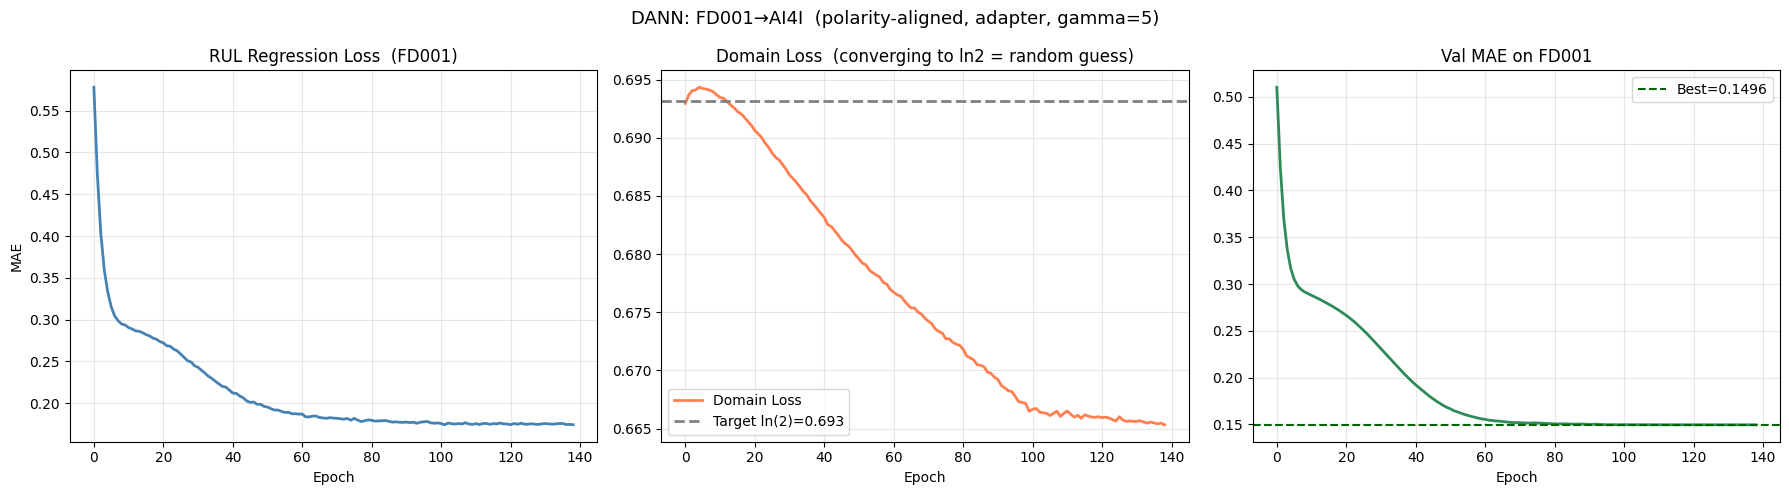

Domain loss final:  0.6653
Convergence score:  0.0278   (target < 0.05)


In [15]:
# ── CELL 12: Training Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(rul_losses, color='steelblue', linewidth=2)
axes[0].set_title(f'RUL Regression Loss  ({SOURCE_DS})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE'); axes[0].grid(alpha=0.3)

axes[1].plot(dom_losses, color='coral', linewidth=2, label='Domain Loss')
axes[1].axhline(np.log(2), color='gray', linestyle='--', linewidth=2,
                label=f'Target ln(2)={np.log(2):.3f}')
axes[1].set_title('Domain Loss  (converging to ln2 = random guess)')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(val_maes, color='seagreen', linewidth=2)
axes[2].axhline(best_val, color='darkgreen', linestyle='--',
                label=f'Best={best_val:.4f}')
axes[2].set_title(f'Val MAE on {SOURCE_DS}')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(
    f'DANN: {SOURCE_DS}→{TARGET_DS}  (polarity-aligned, adapter, gamma=5)',
    fontsize=13
)
plt.tight_layout(); plt.show()

conv = abs(dom_losses[-1] - np.log(2))
print(f'Domain loss final:  {dom_losses[-1]:.4f}')
print(f'Convergence score:  {conv:.4f}   (target < 0.05)')


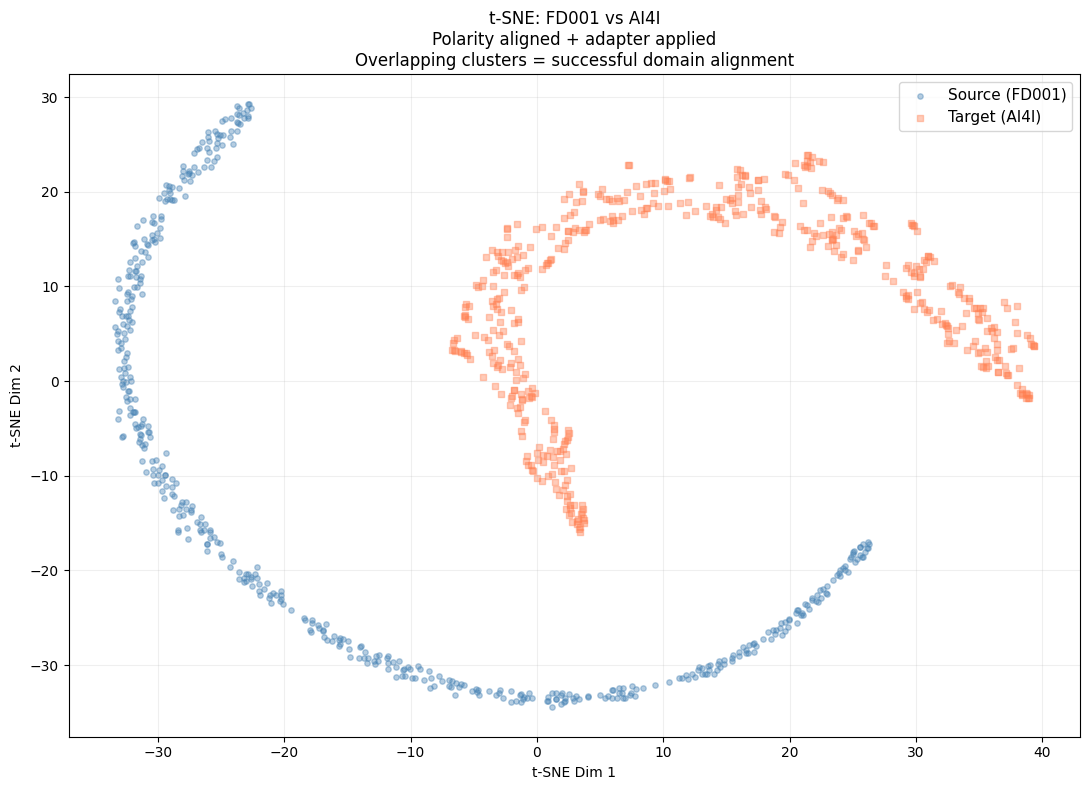

If clusters overlap: polarity alignment + adapter solved the mirror-image problem.
If still separated: the 5 chosen FD001 features have no real semantic overlap
with AI4I features — consider using only 3 features (temperature + wear-proxy).


In [16]:
# ── CELL 14: t-SNE — expect overlap now ──────────────────────────────────────
# After polarity alignment:
#   Both arcs should curve in the SAME direction.
# After adapter training:
#   Residual rotation/scaling is removed.
# Expected: interleaved or overlapping clusters instead of two islands.

feature_extractor = get_cnn_lstm_feature_extractor(dann_model)

# Apply adapter to target features before extracting
N_VIS         = min(500, len(X_src_tr), len(X_tgt))
X_tgt_adapted = adapter_model.predict(X_tgt[:N_VIS], verbose=0, batch_size=128)

feats_src = feature_extractor.predict(X_src_tr[:N_VIS],  verbose=0, batch_size=128)
feats_tgt = feature_extractor.predict(X_tgt_adapted,     verbose=0, batch_size=128)

all_feats  = np.vstack([feats_src, feats_tgt])
all_labels = ([f'Source ({SOURCE_DS})'] * N_VIS +
              [f'Target ({TARGET_DS})'] * N_VIS)

tsne        = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_result = tsne.fit_transform(all_feats)

fig, ax = plt.subplots(figsize=(11, 8))
for label, color, marker in [
    (f'Source ({SOURCE_DS})', 'steelblue', 'o'),
    (f'Target ({TARGET_DS})', 'coral',     's')
]:
    mask = [l == label for l in all_labels]
    ax.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
               c=color, label=label, alpha=0.4, s=15, marker=marker)

ax.set_title(
    f't-SNE: {SOURCE_DS} vs {TARGET_DS}\n'
    f'Polarity aligned + adapter applied\n'
    f'Overlapping clusters = successful domain alignment',
    fontsize=12
)
ax.legend(fontsize=11)
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')
ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

print('If clusters overlap: polarity alignment + adapter solved the mirror-image problem.')
print('If still separated: the 5 chosen FD001 features have no real semantic overlap')
print('with AI4I features — consider using only 3 features (temperature + wear-proxy).')


In [17]:
# ── CELL 16: Zero-Shot AI4I Evaluation ───────────────────────────────────────
# Apply the same polarity flip + adapter to evaluation windows.


def construct_ai4i_rul_toolwear(df_raw, max_rul=125):
    df       = segment_ai4i_by_wear_reset(df_raw)
    max_wear = df.groupby('unit_id')['Tool wear [min]'].max().rename('max_wear')
    df       = df.merge(max_wear, on='unit_id')
    df['RUL'] = (df['max_wear'] - df['Tool wear [min]']).clip(upper=max_rul)
    return df.drop(columns=['max_wear'])


ai4i_with_rul = construct_ai4i_rul_toolwear(ai4i_raw)

# Apply scaler then polarity flip (same pipeline as Cell 6)
X_eval_raw    = ai4i_raw[AI4I_SENSOR_COLS].values.astype(np.float32)
X_eval_scaled = ai4i_scaler.transform(X_eval_raw)
X_eval_aligned = X_eval_scaled.copy()
for i in range(DANN_N_FEAT):
    if FLIP_MASK[i]:
        X_eval_aligned[:, i] = 1.0 - X_eval_aligned[:, i]

df_eval = pd.DataFrame(X_eval_aligned, columns=tgt_feature_cols)
df_eval['unit_id'] = ai4i_with_rul['unit_id'].values
df_eval['cycle']   = ai4i_with_rul['cycle'].values
df_eval['RUL']     = (ai4i_with_rul['RUL'].values / MAX_RUL).astype(np.float32)

# ALL lifecycle windows
X_eval_all, y_norm, _ = create_windows(
    df_eval, tgt_feature_cols, WINDOW_SIZE, rul_col='RUL'
)
y_true = y_norm * MAX_RUL

# Apply adapter before prediction
X_eval_adapted = adapter_model.predict(
    X_eval_all.astype(np.float32), verbose=0, batch_size=256
)
y_pred = reg_model.predict(
    X_eval_adapted.astype(np.float32), verbose=0, batch_size=256
).flatten() * MAX_RUL

ai4i_rmse = round(float(np.sqrt(np.mean((y_pred - y_true)**2))), 2)
ai4i_mae  = round(float(np.mean(np.abs(y_pred - y_true))), 2)

print(f'DANN + polarity alignment + adapter on AI4I (zero-shot, full lifecycle):')
print(f'  RMSE: {ai4i_rmse:.2f} cycles')
print(f'  MAE:  {ai4i_mae:.2f} cycles')
print(f'\ny_true: mean={y_true.mean():.1f} | range=[{y_true.min():.0f}, {y_true.max():.0f}]')


DANN + polarity alignment + adapter on AI4I (zero-shot, full lifecycle):
  RMSE: 38.86 cycles
  MAE:  30.48 cycles

y_true: mean=68.0 | range=[0, 125]


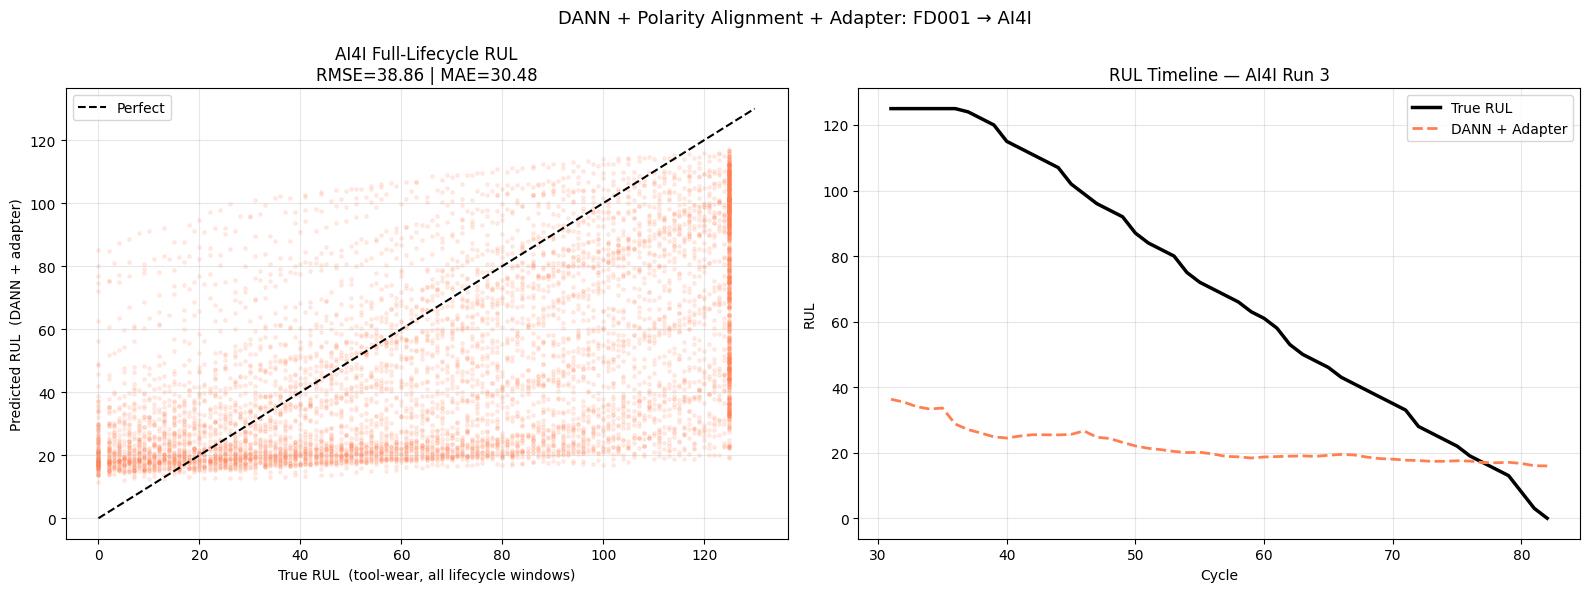

In [18]:
# ── CELL 17: RUL Scatter Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_true, y_pred, alpha=0.12, s=6, color='coral')
lim = max(y_true.max(), y_pred.max()) + 5
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('True RUL  (tool-wear, all lifecycle windows)')
axes[0].set_ylabel('Predicted RUL  (DANN + adapter)')
axes[0].set_title(f'AI4I Full-Lifecycle RUL\nRMSE={ai4i_rmse:.2f} | MAE={ai4i_mae:.2f}')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Timeline for sample run
sample_run = 3
run_mask = df_eval['unit_id'] == sample_run
run_df   = df_eval[run_mask].sort_values('cycle')

if len(run_df) >= WINDOW_SIZE:
    X_run = create_windows_for_unit_lifecycle(run_df, tgt_feature_cols, WINDOW_SIZE)
    X_run_adapted = adapter_model.predict(X_run.astype(np.float32), verbose=0)
    y_run_pred = reg_model.predict(
        X_run_adapted.astype(np.float32), verbose=0
    ).flatten() * MAX_RUL
    y_run_true = run_df['RUL'].values[WINDOW_SIZE:] * MAX_RUL
    cycles     = run_df['cycle'].values[WINDOW_SIZE:]

    axes[1].plot(cycles, y_run_true, 'k-',   linewidth=2.5, label='True RUL')
    axes[1].plot(cycles, y_run_pred, 'coral', linewidth=2,
                 linestyle='--', label='DANN + Adapter')
    axes[1].set_xlabel('Cycle'); axes[1].set_ylabel('RUL')
    axes[1].set_title(f'RUL Timeline — AI4I Run {sample_run}')
    axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('DANN + Polarity Alignment + Adapter: FD001 → AI4I', fontsize=13)
plt.tight_layout(); plt.show()
